In [1]:
import math
import multiprocessing

import torch
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader

import os
import json

import numpy as np
import scipy.stats

from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import LoggerType
from accelerate.utils import tqdm
from accelerate import DistributedDataParallelKwargs
from transformers import AutoTokenizer, BertTokenizerFast

from lib.dataset.dataset import UnifiedScanpath
from lib.evaluation.pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from lib.models.loss import CrossEntropyLoss, MLPLogNormalDistribution, LogAction, LogDuration, AlignmentLoss
from lib.scst.cider.cider import Cider
from lib.scst.ciderR.ciderR import CiderR
from lib.scst.tokenizer import tokenizer
from opts import parse_opt

from lib.utils.checkpointing import CheckpointManager
from lib.utils.recording import RecordManager
from lib.evaluation.evaluator import Evaluator

import lib.models.models
import lib.models.gazeformer_explanation_alignment

from lib.models.sample.sampling import Sampling

os.environ["TOKENIZERS_PARALLELISM"] = "false"

/root/miniconda/envs/GazeXplain/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
with open('/repo/GazeXplain/runs/COCO_TP_runX_w_resp_vlm_based_full_search18_v4/hparams.json', 'r') as fp:
    args = json.load(fp)

In [3]:
import argparse

In [4]:
args = argparse.Namespace(**args)

In [5]:
args

Namespace(mode='train', dataset_dir='/repo/GazeXplain/CocoSearch//', datasets=['COCO-TP'], tiny=False, search_dataset='search18', use_responses=True, unseen=False, vlm_based=True, batch=32, test_batch=48, epochs=10, pct_start=0.05, seed=0, lr=0.0001, weight_decay=5e-05, resume_dir='', eval_repeat_num=1, dropout=0.2, checkpoint_every=1, width=512, height=384, im_h=24, im_w=32, blur_sigma=None, min_length=1, max_length=16, patch_size=16, num_encoder=6, num_decoder=6, hidden_dim=512, nhead=8, img_hidden_dim=2048, lm_hidden_dim=768, encoder_dropout=0.1, decoder_dropout=0.2, cls_dropout=0.4, activation='relu', normalize_before=False, return_intermediate_dec=False, with_tracking=False, fp16=False, mixed_precision=None, cpu=False, project_dir='runs/COCO_TP_runX_w_resp_vlm_based_full_search18', project_name='ExplanationScanpath', warmup_epoch=1, start_rl_epoch=8, rl_sample_number=3, rl_lr_initial_decay=0.1, checkpoint_every_rl=1, supervised_save=True, explanation=True, max_generation_length=20

In [6]:
train_dataset = UnifiedScanpath(split="train", opt=args)

# Instantiate dataloaders.
train_all_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=train_dataset.collate_func
)

In [7]:
transformer = lib.models.models.Transformer(args=args)
model = lib.models.gazeformer_explanation_alignment.gazeformer(transformer=transformer, args=args)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BlipTextLMHeadModel were not initialized from the model checkpoint at Salesforce/blip-image-captioning-base and are newly initialized: ['encoder.layer.1.attention.output.LayerNorm.bias', 'encoder.layer.6.intermediate.dense.bias', 'encoder.layer.10.crossattention.self.value.weight', 'encoder.layer.11.output.LayerNorm.weight', 'encoder.layer.7.output.LayerNorm.bias', 'encoder.layer.5.crossattention.self.query.bias', 'encoder.layer.8.crossattention.self.value.weight', 'encoder.layer.11.intermediate.dense.weight', 'cls.predictions.transform.dense.bias', 'encoder.layer.5.crossattention.self.value.weight', 'encoder.layer.5.attention.output.dense.weight', 'encoder.layer.11.crossattention.out

In [8]:
transformer

Transformer(
  (cross_att): CrossAttentionPredictor(
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
    (dropout3): Dropout(p=0.2, inplace=False)
    (norm_vlm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (norm3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=512, bias=True)
    (querypos_embed1): Embedding(1200, 512)
    (querypos_embed2): Embedding(768, 512)
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (multihead_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (linear1): Linear(in_features=512, out_features=512, bias=True)
    (dropout): Dropout(p=0.2, inp

In [9]:
transformer = transformer.to('cuda')
model = model.to('cuda')

In [10]:
transformer

Transformer(
  (cross_att): CrossAttentionPredictor(
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
    (dropout3): Dropout(p=0.2, inplace=False)
    (norm_vlm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (norm3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=512, bias=True)
    (querypos_embed1): Embedding(1200, 512)
    (querypos_embed2): Embedding(768, 512)
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (multihead_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (linear1): Linear(in_features=512, out_features=512, bias=True)
    (dropout): Dropout(p=0.2, inp

In [11]:
model

gazeformer(
  (transformer): Transformer(
    (cross_att): CrossAttentionPredictor(
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
      (dropout3): Dropout(p=0.2, inplace=False)
      (norm_vlm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (proj): Linear(in_features=2048, out_features=512, bias=True)
      (querypos_embed1): Embedding(1200, 512)
      (querypos_embed2): Embedding(768, 512)
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
      )
      (multihead_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
      )
      (linear1): Linear(in_features=51

In [12]:
with torch.no_grad():
    for i in train_all_dataloader:
        batch = {k: v.to('cuda') if not isinstance(v, list) else v for k, v in i.items()}
        out = model(batch)
        break

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [13]:
out

{'actions': tensor([[[-0.7186, -7.2384, -7.1969,  ..., -7.2026, -7.2422, -8.0079],
          [-0.7769, -7.2005, -7.1698,  ..., -7.5036, -6.7659, -7.0264],
          [-0.7210, -7.0167, -7.1388,  ..., -7.1849, -7.4016, -7.3676],
          ...,
          [-0.8895, -7.3342, -7.2329,  ..., -7.2248, -7.4883, -7.1033],
          [-0.7244, -8.4483, -7.4696,  ..., -7.8854, -7.0276, -7.3052],
          [-0.6905, -7.3752, -7.4612,  ..., -7.2302, -7.3615, -7.6060]],
 
         [[-0.8551, -6.8699, -7.4131,  ..., -7.3127, -7.3374, -7.1822],
          [-0.5025, -7.3088, -7.6008,  ..., -8.1592, -7.3056, -7.3439],
          [-0.7445, -7.7160, -7.0645,  ..., -7.7475, -7.6417, -7.3492],
          ...,
          [-0.4347, -8.9924, -7.4834,  ..., -7.5585, -7.3151, -7.8007],
          [-0.7195, -6.9051, -7.0732,  ..., -7.0521, -7.0563, -7.7431],
          [-0.4991, -7.1042, -7.4147,  ..., -7.3568, -7.4416, -7.6266]],
 
         [[-0.6645, -7.1415, -7.9027,  ..., -7.3849, -7.1407, -8.4382],
          [-0.548

In [14]:
out['multimodal_similarity'][0].shape

torch.Size([16, 16])

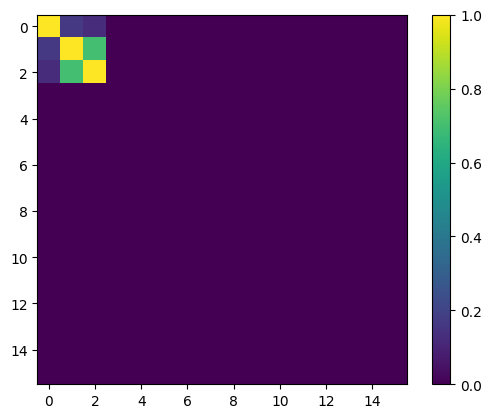

In [15]:
from matplotlib import pyplot  as plt
plt.imshow(out['resnet_visual_similarity'][9].cpu())
plt.colorbar()

In [16]:
batch["target_scanpath"].shape, batch["action_mask"].shape

(torch.Size([32, 16, 769]), torch.Size([32, 16]))

In [17]:
batch["target_scanpath"]

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0., 

In [18]:
batch["action_mask"]

tensor([[1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0

In [19]:
!nvidia-smi

Wed Oct 29 14:11:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:01:02.0 Off |                    0 |
| N/A   31C    P0             60W /  300W |   10173MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [20]:
src = torch.randn(2, 24, 512).to('cuda')
tgt = torch.randn(2, 7, 3).to('cuda')
task = torch.randn(2, 512).to('cuda')

with torch.no_grad():
    a = transformer.decoder.decoder(task, src)

AssertionError: For unbatched (2-D) `query`, expected `key` and `value` to be 2-D but found 3-D and 3-D tensors respectively

In [ ]:
transformer.forward()